#Problem Statement:

You are a Data Scientist in a big firm. You have to develop a deep learning model to perform sentiment analysis on a dataset of tweets related to various candidates.

#Tasks to be Performed:

##Data Loading and Preprocessing:

● Load the tweet data from a CSV file.

● Filter out the relevant columns: 'candidate', 'sentiment', and 'text'.

● Preprocess the text data by removing stop words, punctuation, converting to lowercase, and other cleaning steps.


##Text Vectorization:
Convert the preprocessed text data into numerical format using tokenization and padding, so that it can be fed into a deep learning model.

##Model Development:
Develop a deep learning model using TensorFlow and Keras. The model includes an Embedding layer, a SpatialDropout1D layer to prevent overfitting, an LSTM layer for sequence data processing, and a Dense layer for output. It aims to classify the sentiment of each tweet into one of the three categories.

##Model Training and Evaluation:
● Train the model on the processed text data, using categorical cross-entropy as the loss function, and accuracy as the evaluation metric.

● Use a validation split to evaluate the model's performance and prevent overfitting.



#Install & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SpatialDropout1D, LSTM, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow version: {tf.__version__}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


TensorFlow version: 2.20.0


#Load Data

In [2]:
df=pd.read_csv('/content/twitter_training.csv')

In [3]:
df.head(5)

,ID,candidate,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())

Dataset shape: (74682, 4)

First 5 rows:
     ID    candidate sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  

Column names: ['ID', 'candidate', 'sentiment', 'text']


Select Relevant Columns & Explore


Sentiment distribution:
sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64


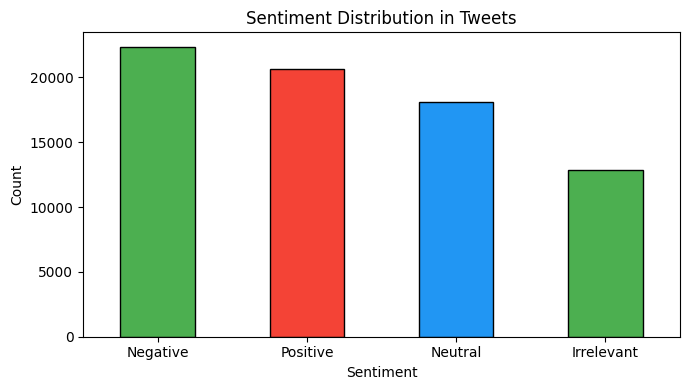

In [5]:
df = df[['candidate', 'sentiment', 'text']].copy()
df.dropna(inplace=True)

print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

plt.figure(figsize=(7, 4))
df['sentiment'].value_counts().plot(kind='bar', color=['#4CAF50', '#F44336', '#2196F3'],
                                     edgecolor='black')
plt.title('Sentiment Distribution in Tweets')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150)
plt.show()

Text Preprocessing

In [6]:
stop_words = set(stopwords.words('english'))

In [7]:
def clean_text(text: str) -> str:
    """
    Cleans a tweet by:
    - Lowercasing
    - Removing URLs
    - Removing mentions (@user) and hashtags (#tag)
    - Removing punctuation
    - Removing digits
    - Removing extra whitespace
    - Removing stop words
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)          # URLs
    text = re.sub(r"@\w+|#\w+", "", text)                        # mentions & hashtags
    text = text.translate(str.maketrans("", "", string.punctuation))  # punctuation
    text = re.sub(r"\d+", "", text)                               # digits
    text = re.sub(r"\s+", " ", text).strip()                     # extra spaces
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

print("\nSample cleaned tweets:")
print(df[['text', 'clean_text']].head(5).to_string(index=False))


Sample cleaned tweets:
                                                     text                    clean_text
    im getting on borderlands and i will murder you all , im getting borderlands murder
      I am coming to the borders and I will kill you all,           coming borders kill
       im getting on borderlands and i will kill you all,   im getting borderlands kill
      im coming on borderlands and i will murder you all,  im coming borderlands murder
im getting on borderlands 2 and i will murder you me all, im getting borderlands murder


Encode Labels

In [8]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])
num_classes = len(label_encoder.classes_)

print(f"\nClasses: {label_encoder.classes_}")
print(f"Number of classes: {num_classes}")
print(df[['sentiment', 'label']].drop_duplicates())


Classes: ['Irrelevant' 'Negative' 'Neutral' 'Positive']
Number of classes: 4
      sentiment  label
0      Positive      3
12      Neutral      2
24     Negative      1
102  Irrelevant      0


Text Vectorisation (Tokenization + Padding)

In [9]:
MAX_VOCAB_SIZE = 10_000   # Top-N most frequent words
MAX_SEQ_LENGTH = 100      # Pad/truncate all sequences to this length
EMBEDDING_DIM  = 64       # Size of the embedding vectors

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
padded    = pad_sequences(sequences, maxlen=MAX_SEQ_LENGTH,
                          padding='post', truncating='post')

# One-hot encode labels for categorical cross-entropy
labels_cat = to_categorical(df['label'], num_classes=num_classes)

print(f"\nVocabulary size : {len(tokenizer.word_index)}")
print(f"Padded shape    : {padded.shape}")
print(f"Labels shape    : {labels_cat.shape}")


Vocabulary size : 38734
Padded shape    : (73996, 100)
Labels shape    : (73996, 4)


Train / Validation Split

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    padded, labels_cat,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"\nTraining samples   : {X_train.shape[0]}")
print(f"Validation samples : {X_val.shape[0]}")


Training samples   : 59196
Validation samples : 14800


Build the Deep Learning Model

In [11]:
def build_model(vocab_size, embedding_dim, max_len, num_classes):
    model = Sequential([
        # 1. Embedding layer — maps word indices to dense vectors
        Embedding(input_dim=vocab_size,
                  output_dim=embedding_dim,
                  input_length=max_len,
                  name='embedding'),

        # 2. SpatialDropout1D — drops entire feature maps to reduce overfitting
        SpatialDropout1D(0.3, name='spatial_dropout'),

        # 3. LSTM — learns long-range dependencies in the sequence
        LSTM(128, dropout=0.2, recurrent_dropout=0.2, name='lstm'),

        # 4. Dense hidden layer with ReLU
        Dense(64, activation='relu', name='dense_hidden'),
        Dropout(0.3, name='dropout'),

        # 5. Output layer — softmax for multi-class classification
        Dense(num_classes, activation='softmax', name='output'),
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        metrics=['accuracy']
    )
    return model


model = build_model(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    max_len=MAX_SEQ_LENGTH,
    num_classes=num_classes
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Callbacks

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

Train the Model

In [13]:
EPOCHS     = 30
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 674s 359ms/step - accuracy: 0.2998 - loss: 1.3685 - val_accuracy: 0.3022 - val_loss: 1.3666 - learning_rate: 0.0010
Epoch 2/30
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 647s 349ms/step - accuracy: 0.3012 - loss: 1.3674 - val_accuracy: 0.3022 - val_loss: 1.3668 - learning_rate: 0.0010
Epoch 3/30
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 658s 356ms/step - accuracy: 0.3018 - loss: 1.3673 - val_accuracy: 0.3022 - val_loss: 1.3672 - learning_rate: 0.0010
Epoch 4/30
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.3012 - loss: 1.3677
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 661s 357ms/step - accuracy: 0.3023 - loss: 1.3671 - val_accuracy: 0.3022 - val_loss: 1.3674 - learning_rate: 0.0010
Epoch 5/30
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 669s 362ms/step - accuracy: 0.3022 - loss: 1.3668 - val_accuracy: 0.3022 - val_loss: 1.3667 - learning_rate: 5.0000e-04
Epoch 6/30
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 674s 364m

Plot Training History

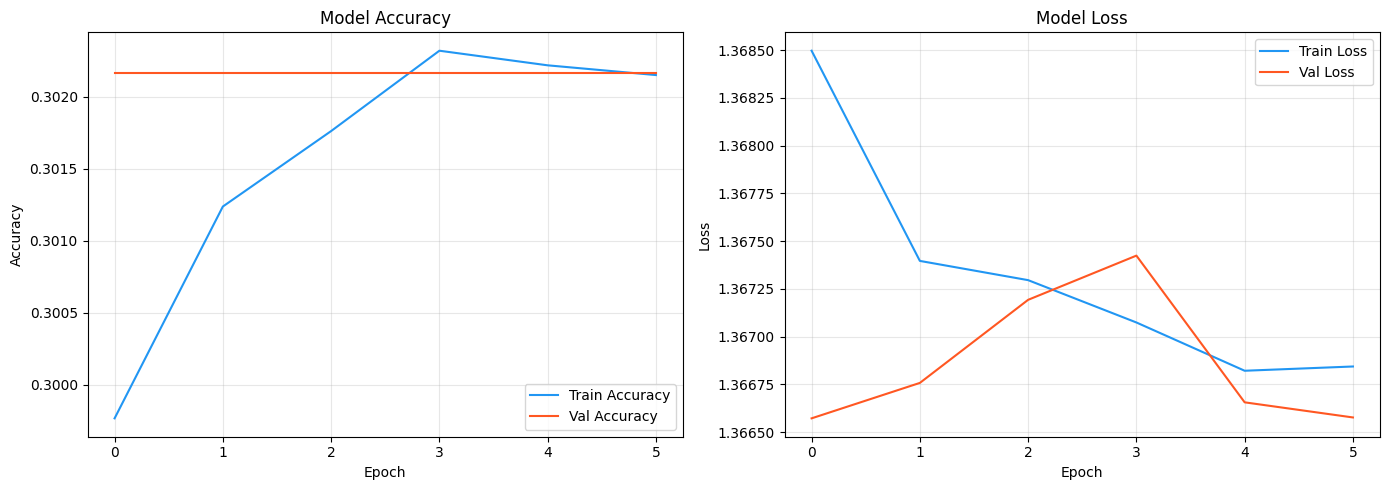

In [14]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='#2196F3')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#FF5722')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='#2196F3')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#FF5722')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    plt.show()

plot_history(history)

Evaluate on Validation Set

In [15]:
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"\nValidation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")


Validation Loss     : 1.3666
Validation Accuracy : 0.3022


Classification Report & Confusion Matrix

463/463 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.00      0.00      0.00      2575
    Negative       0.30      1.00      0.46      4472
     Neutral       0.00      0.00      0.00      3622
    Positive       0.00      0.00      0.00      4131

    accuracy                           0.30     14800
   macro avg       0.08      0.25      0.12     14800
weighted avg       0.09      0.30      0.14     14800



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


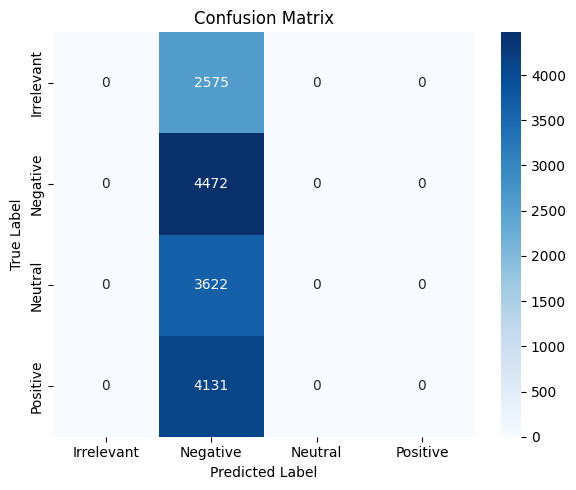

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = model.predict(X_val)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_val,       axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                             target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

Predict on New Tweets

In [17]:
def predict_sentiment(tweet: str) -> str:
    """Returns predicted sentiment for a raw tweet string."""
    cleaned  = clean_text(tweet)
    seq      = tokenizer.texts_to_sequences([cleaned])
    padded_s = pad_sequences(seq, maxlen=MAX_SEQ_LENGTH,
                             padding='post', truncating='post')
    probs    = model.predict(padded_s, verbose=0)[0]
    idx      = np.argmax(probs)
    label    = label_encoder.inverse_transform([idx])[0]
    confidence = probs[idx] * 100
    return f"Sentiment: {label}  |  Confidence: {confidence:.1f}%"

# Demo predictions
test_tweets = [
    "Absolutely love this candidate! They have the best policies.",
    "I can't stand this politician. They ruin everything they touch.",
    "The candidate gave a speech at the convention today.",
]

print("\n── Sample Predictions ──")
for tweet in test_tweets:
    result = predict_sentiment(tweet)
    print(f"Tweet   : {tweet}")
    print(f"Result  : {result}\n")


── Sample Predictions ──
Tweet   : Absolutely love this candidate! They have the best policies.
Result  : Sentiment: Negative  |  Confidence: 30.3%

Tweet   : I can't stand this politician. They ruin everything they touch.
Result  : Sentiment: Negative  |  Confidence: 30.3%

Tweet   : The candidate gave a speech at the convention today.
Result  : Sentiment: Negative  |  Confidence: 30.3%



Save the Model

In [18]:
model.save("tweet_sentiment_lstm.keras")
print("Model saved to tweet_sentiment_lstm.keras")

Model saved to tweet_sentiment_lstm.keras
